In [5]:
import os, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.io as sio
from scipy.signal import butter, sosfiltfilt
from sklearn.preprocessing import LabelEncoder,StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import mne
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Conv1D,Conv2D, MaxPooling1D,
                                     BatchNormalization, GlobalAveragePooling1D,
                                     Bidirectional, Flatten, Activation,
                                     DepthwiseConv2D, SeparableConv2D, AveragePooling2D)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import ReduceLROnPlateau

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


In [6]:
# Global class names mapping
class_names = ["Focused", "Distracted", "Fatigued", "Stressed", "Other"]
target_names = class_names

Step 1: Data Loading

In [7]:
folder1 = Path(r"C:\Users\Cyan\Desktop\DataScience_Notes\DataScience_Capstone\EEG Data")
folder2 = Path(r"C:\Users\Cyan\Desktop\DataScience_Notes\DataScience_Capstone\eeg-during-mental-arithmetic-tasks-1.0.0")

all_files = [str(f) for f in folder1.glob("*.mat")] + [str(f) for f in folder1.glob("*.edf")]
all_files += [str(f) for f in folder2.glob("*.mat")] + [str(f) for f in folder2.glob("*.edf")]

print("Found", len(all_files), "files")

def load_mat_file(path):
    mat = sio.loadmat(path)
    o_struct = mat['o'][0,0]
    eeg_data = np.asarray(o_struct['data'])
    fs = int(o_struct['sampFreq'][0,0])
    subject_id = o_struct['id'][0]
    markers = o_struct['marker'].flatten()
    trials = o_struct['trials']
    return eeg_data, fs, subject_id, markers, trials

# 
fname = all_files[0] 
# Load depending on file type
if fname.endswith(".mat"):
    eeg_data, fs, subject_id, markers, trials = load_mat_file(fname)
    ch = eeg_data[:,0]        # first channel as signal array
    sf = fs                   # sampling frequency (int)
elif fname.endswith(".edf"):
    raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
    data, sf = raw.get_data(), int(raw.info['sfreq'])
    ch = data[0]              # first channel as signal array
else:
    raise ValueError("Unsupported file format")





Found 70 files


EEG shape: (351204, 25)
Sampling frequency: 128
Subject ID: 201410211925.D091BB44
Markers shape: (351204,)
Trials shape: (1, 2, 14, 128)


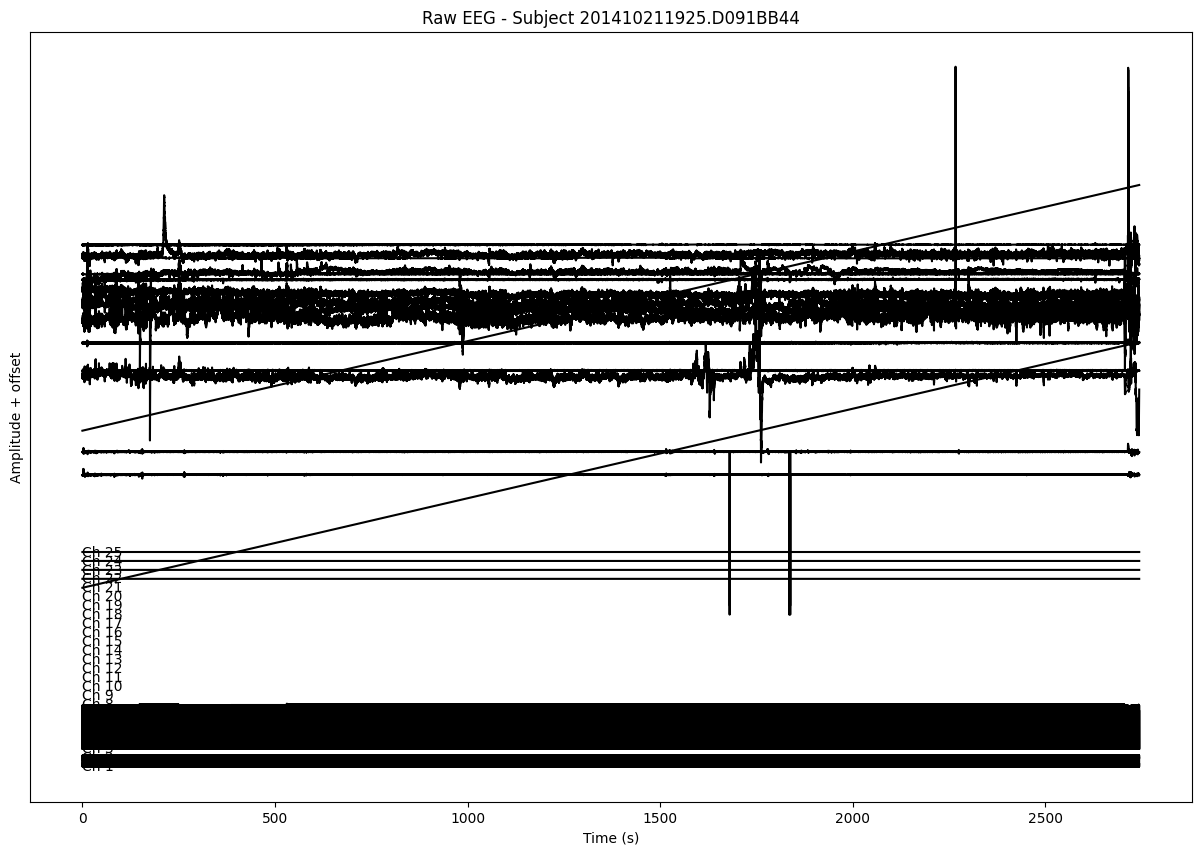

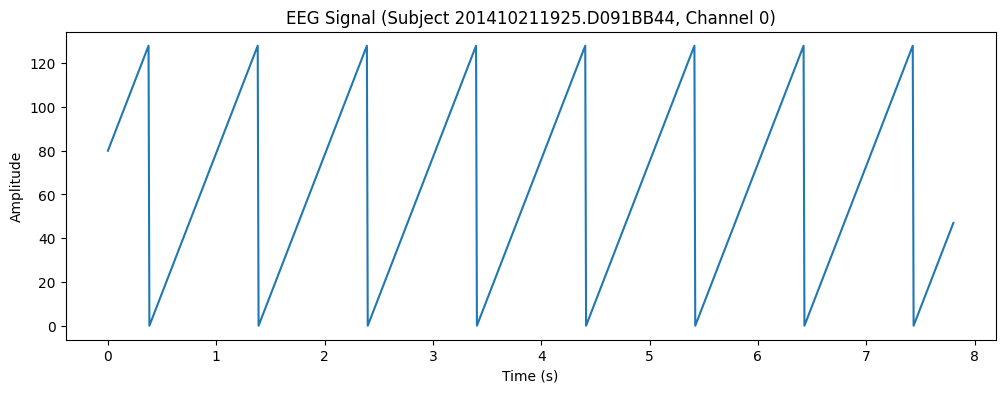

In [8]:

#
fname = r"C:\Users\Cyan\Desktop\DataScience_Notes\DataScience_Capstone\EEG Data\eeg_record5.mat"
eeg_data, fs, subject_id, markers, trials = load_mat_file(fname)

print("EEG shape:", eeg_data.shape)
print("Sampling frequency:", fs)
print("Subject ID:", subject_id)
print("Markers shape:", markers.shape)
print("Trials shape:", trials.shape)

# Plot stacked EEG channels (hospital-style view)
n_samples, n_channels = eeg_data.shape
time = np.arange(n_samples) / fs
offset = 100

plt.figure(figsize=(15, 10))
for ch in range(n_channels):
    plt.plot(time, eeg_data[:, ch] + ch * offset, color='black')
    plt.text(-0.5, ch * offset, f"Ch {ch+1}", va='center')
plt.title(f"Raw EEG - Subject {subject_id}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude + offset")
plt.yticks([])
plt.show()

# Plot first 1000 samples of channel 0
plt.figure(figsize=(12,4))
plt.plot(time[:1000], eeg_data[:1000, 0], color='tab:blue')
plt.title(f"EEG Signal (Subject {subject_id}, Channel 0)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


In [9]:
# Visualizing edf files

# Path to the EDF file
fname = r"C:\Users\Cyan\Desktop\DataScience_Notes\DataScience_Capstone\eeg-during-mental-arithmetic-tasks-1.0.0\Subject00_1.edf"


# For .edf files
raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
data, sf = raw.get_data(), int(raw.info['sfreq'])
ch = data[0]              # first channel as signal array

Channels: 21
Sampling frequency: 500
Data shape: (21, 91000)


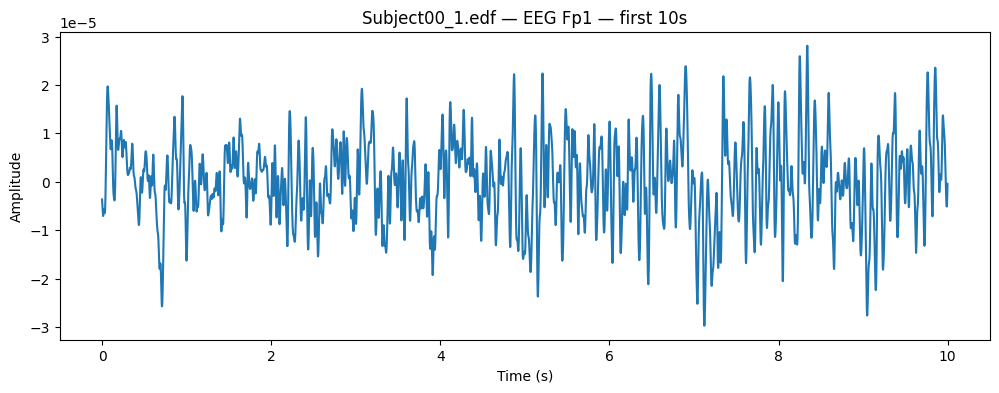

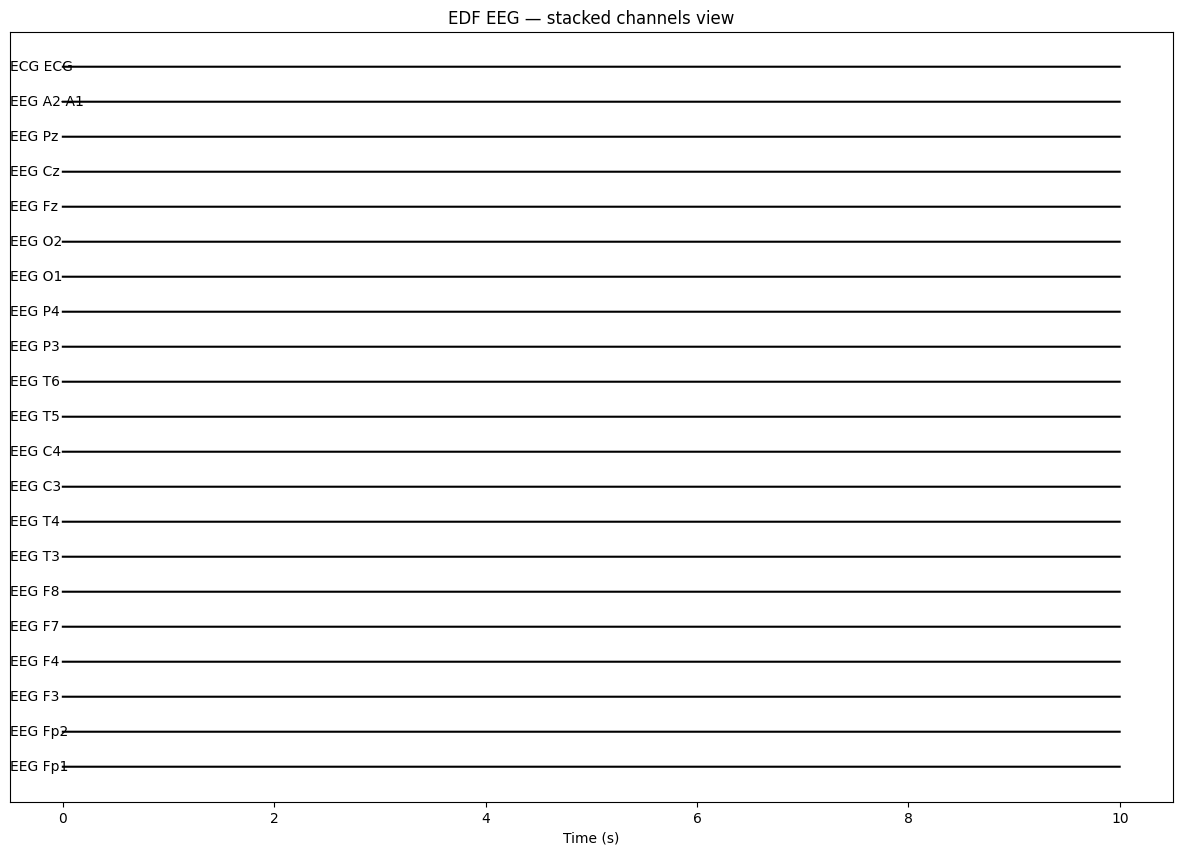

In [10]:

# Extract data and metadata
data = raw.get_data()            # shape: (n_channels, n_samples)
sf = int(raw.info['sfreq'])      # sampling frequency
ch_names = raw.ch_names

print("Channels:", len(ch_names))
print("Sampling frequency:", sf)
print("Data shape:", data.shape)

# Plot first channel (first 10 seconds)
seconds_to_plot = 10
ch0 = data[0]
n_plot = min(len(ch0), int(seconds_to_plot * sf))
t = np.arange(n_plot) / sf

plt.figure(figsize=(12,4))
plt.plot(t, ch0[:n_plot], color='tab:blue')
plt.title(f"{Path(fname).name} — {ch_names[0]} — first {seconds_to_plot}s")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Hospital-style stacked plot of all channels
plt.figure(figsize=(15,10))
offset = 100
for i, ch in enumerate(data):
    plt.plot(t, ch[:n_plot] + i*offset, color='black')
    plt.text(-0.5, i*offset, ch_names[i], va='center')
plt.title("EDF EEG — stacked channels view")
plt.xlabel("Time (s)")
plt.yticks([])
plt.show()


Step 2: Preprocessing

In [11]:
def bandpass_filter(signal, sf, low=1, high=50, order=4):
    sos = butter(order, [low, high], btype='band', fs=sf, output='sos')
    return sosfiltfilt(sos, signal)

def segment_signal(signal, sf, window_sec=2, step_sec=1):
    epoch_len, step = int(window_sec*sf), int(step_sec*sf)
    return [signal[i:i+epoch_len] for i in range(0, len(signal)-epoch_len+1, step)]

def normalize_epoch(epoch):
    return StandardScaler().fit_transform(epoch.reshape(-1,1)).flatten()


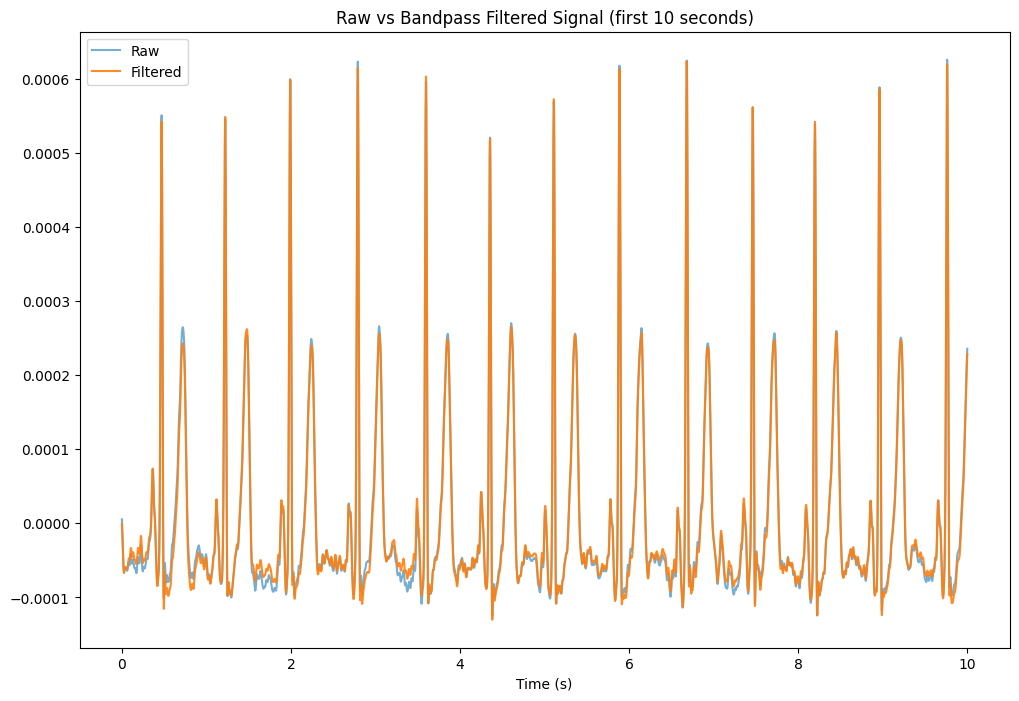

In [12]:
# Ensure ch is the EEG signal array and sf is the sampling frequency (int)
# Example: ch = eeg_data[:,0], sf = fs

# Apply bandpass filter first
ch_filtered = bandpass_filter(ch, sf)

# Slice the first N samples safely (up to 10 seconds)
N = min(len(ch), 10 * sf)
raw_segment = ch[:N]
filtered_segment = ch_filtered[:N]

# Time axis
t = np.arange(N) / sf

# Plot raw vs filtered
plt.figure(figsize=(12,8))
plt.plot(t, raw_segment, label='Raw', alpha=0.6)
plt.plot(t, filtered_segment, label='Filtered', alpha=0.9)
plt.title("Raw vs Bandpass Filtered Signal (first 10 seconds)")
plt.xlabel("Time (s)")
plt.legend()
plt.show()


Feature Extraction

In [13]:
import numpy as np
from scipy.signal import welch

def hjorth_params(signal):
    """
    Hjorth parameters: Activity, Mobility, Complexity
    """
    activity = np.var(signal)

    diff1 = np.diff(signal)
    var_diff1 = np.var(diff1)
    mobility = np.sqrt(var_diff1 / activity) if activity > 0 else 0

    diff2 = np.diff(diff1)
    var_diff2 = np.var(diff2)
    mobility_diff1 = np.sqrt(var_diff2 / var_diff1) if var_diff1 > 0 else 0
    complexity = mobility_diff1 / mobility if mobility > 0 else 0

    return activity, mobility, complexity

def bandpower(epoch, sf, band, window_sec=None):
    low, high = band
    nperseg = window_sec * sf if window_sec else sf * 2
    freqs, psd = welch(epoch, sf, nperseg=nperseg)
    freq_res = freqs[1] - freqs[0]
    idx_band = np.logical_and(freqs >= low, freqs <= high)
    return np.sum(psd[idx_band]) * freq_res

def spectral_entropy(epoch, sf, normalize=True):
    freqs, psd = welch(epoch, sf, nperseg=sf*2)
    psd_norm = psd / np.sum(psd)
    entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
    if normalize:
        entropy /= np.log2(len(psd_norm))
    return entropy

#  Base feature extractor
def extract_features(epoch, sf):
    feats = {}
    feats["theta"] = bandpower(epoch, sf, (4, 8))
    feats["alpha"] = bandpower(epoch, sf, (8, 12))
    feats["beta"]  = bandpower(epoch, sf, (12, 30))
    feats["gamma"] = bandpower(epoch, sf, (30, 45))
    feats["mean"]  = np.mean(epoch)
    feats["var"]   = np.var(epoch)

    hj_a, hj_m, hj_c = hjorth_params(epoch)
    feats["hjorth_activity"]   = hj_a
    feats["hjorth_mobility"]   = hj_m
    feats["hjorth_complexity"] = hj_c

    feats["spectral_entropy"] = spectral_entropy(epoch, sf)
    return feats

#  Extended extractor with ratios
def extract_features_with_ratios(epoch, sf):
    feats = extract_features(epoch, sf)

    theta, alpha, beta, gamma = feats["theta"], feats["alpha"], feats["beta"], feats["gamma"]

    feats["theta_alpha"] = theta / alpha if alpha > 0 else 0
    feats["beta_alpha"]  = beta / alpha if alpha > 0 else 0
    feats["gamma_beta"]  = gamma / beta if beta > 0 else 0
    feats["theta_beta"]  = theta / beta if beta > 0 else 0

    return feats


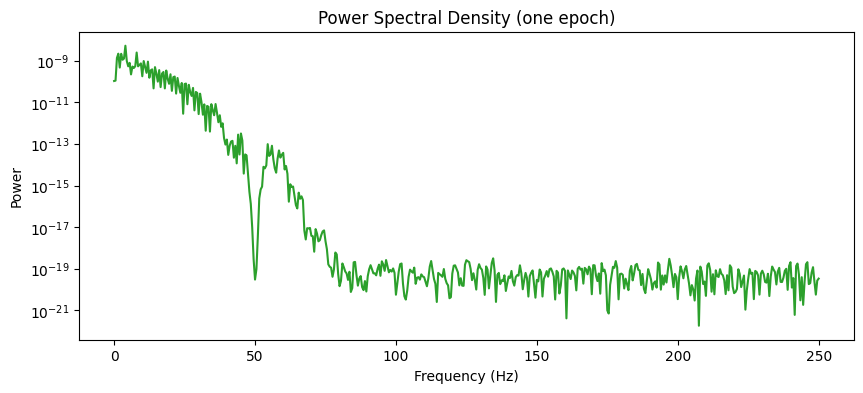

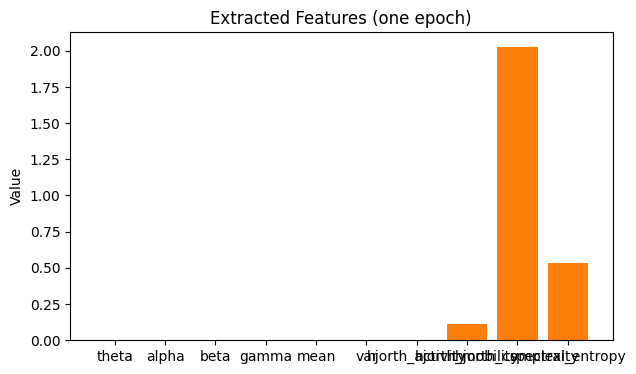

In [14]:
# Take one epoch from your segmented signal
epochs = segment_signal(ch, sf, window_sec=2, step_sec=1)

if len(epochs) > 0:
    epoch = epochs[0]  # pick the first epoch

    # Compute PSD
    freqs, psd = welch(epoch, sf, nperseg=min(len(epoch), sf*2))

    # Plot PSD
    plt.figure(figsize=(10,4))
    plt.semilogy(freqs, psd, color='tab:green')
    plt.title("Power Spectral Density (one epoch)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.show()

    # Extract features
    base_feats = extract_features(epoch, sf)

    # Plot extracted features
    # Extract features
    base_feats = extract_features(epoch, sf)

    # Plot extracted features
    bands = list(base_feats.keys())
    vals = list(base_feats.values())
    plt.figure(figsize=(7,4))
    plt.bar(bands, vals, color='tab:orange')
    plt.title("Extracted Features (one epoch)")
    plt.ylabel("Value")
    plt.show()


Step 3: Dataset building

In [15]:
def compute_thresholds(X):
    """
    Compute thresholds for each feature across all epochs.
    For simplicity, use the median as a decision boundary.
    """
    thresholds = {}
    feature_names = [
        "theta","alpha","beta","gamma",
        "mean","var","hjorth_activity",
        "hjorth_mobility","hjorth_complexity",
        "spectral_entropy",
        "theta_alpha","beta_alpha","gamma_beta","theta_beta"
    ]
    for i, name in enumerate(feature_names):
        thresholds[name] = np.median(X[:, i])
    return thresholds


def map_condition_rule(features, thresholds):
    """
    Map extracted features (including ratios) to a condition label.
    Returns: 0=Focused, 1=Distracted, 2=Fatigued, 3=Stressed, 4=Other
    """
    # Base features
    theta, alpha, beta, gamma, mean, var, hj_a, hj_m, hj_c, spec_ent = features[:10]
    # Band ratios
    theta_alpha, beta_alpha, gamma_beta, theta_beta = features[10:14]

    # Rule logic using ratios + base features
    if theta_alpha > thresholds["theta_alpha"]:
        return 2  # Fatigued
    elif beta_alpha > thresholds["beta_alpha"]:
        return 1  # Distracted
    elif alpha > thresholds["alpha"] and beta < thresholds["beta"]:
        return 0  # Focused
    elif spec_ent > thresholds["spectral_entropy"] or gamma_beta > thresholds["gamma_beta"]:
        return 3  # Stressed
    else:
        return 4  # Other


In [16]:
from scipy.signal import resample

def resample_signal(signal, orig_sf, target_sf=128):
    """Resample signal to target sampling frequency."""
    duration = len(signal) / orig_sf
    new_len = int(duration * target_sf)
    return resample(signal, new_len), target_sf

def build_raw_dataset(files, window_sec=2, step_sec=1, target_sf=128):
    X, y = [], []
    for fname in files:
        if fname.endswith(".edf"):
            raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
            data, sf = raw.get_data(), int(raw.info['sfreq'])
            ch = bandpass_filter(data[0], sf)
        elif fname.endswith(".mat"):
            eeg_data, fs, subject_id, markers, trials = load_mat_file(fname)
            ch, sf = bandpass_filter(eeg_data[:,0], fs), fs
        else:
            continue

        #  Resample to target frequency
        ch, sf = resample_signal(ch, sf, target_sf)

        epochs = segment_signal(ch, sf, window_sec, step_sec)
        expected_len = int(window_sec * sf)

        # Compute thresholds for rule-based labeling
        X_tmp = [list(extract_features_with_ratios(ep, sf).values())
                 for ep in epochs if len(ep) == expected_len]
        thresholds = compute_thresholds(np.array(X_tmp))

        for ep in epochs:
            if len(ep) == expected_len:
                ep_norm = normalize_epoch(ep)
                X.append(ep_norm)
                feats = extract_features_with_ratios(ep, sf)
                label = map_condition_rule(list(feats.values()), thresholds)
                y.append(label)

    #  All epochs have the same length
    return np.array(X), np.array(y)


In [17]:
X_raw, y_raw = build_raw_dataset(all_files, window_sec=2, step_sec=1, target_sf=128)


In [18]:
# Check shape
print("Raw EEG dataset shape:", X_raw.shape)
print("Raw EEG labels shape:", y_raw.shape)

# Inspect one epoch
print("First raw epoch (length):", len(X_raw[0]))
print("First raw epoch values:", X_raw[0][:20])  # first 20 samples

# Label distribution
unique, counts = np.unique(y_raw, return_counts=True)
print("Raw EEG label distribution:", dict(zip(unique, counts)))


Raw EEG dataset shape: (103992, 256)
Raw EEG labels shape: (103992,)
First raw epoch (length): 256
First raw epoch values: [0.15230481 0.15941141 0.16578062 0.17141379 0.17630679 0.18046997
 0.18389997 0.18660259 0.18858165 0.18983887 0.19038091 0.19021072
 0.18933403 0.18775666 0.18548392 0.18252307 0.17888072 0.17456461
 0.16958306 0.16394462]
Raw EEG label distribution: {np.int64(0): np.int64(987), np.int64(1): np.int64(49375), np.int64(2): np.int64(51953), np.int64(3): np.int64(1048), np.int64(4): np.int64(629)}


In [19]:
#Feature dataset for RF&XGBoost
def build_feature_dataset(files, window_sec=2, step_sec=1):
    X, y = [], []
    for fname in files:
        if fname.endswith(".edf"):
            raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
            data, sf = raw.get_data(), int(raw.info['sfreq'])
            ch = bandpass_filter(data[0], sf)
        elif fname.endswith(".mat"):
            eeg_data, fs, subject_id, markers, trials = load_mat_file(fname)
            ch, sf = bandpass_filter(eeg_data[:,0], fs), fs
        else:
            continue

        # Segment into epochs
        epochs = segment_signal(ch, sf, window_sec, step_sec)

        # Compute thresholds for rule-based labeling
        X_tmp = [list(extract_features_with_ratios(ep, sf).values()) for ep in epochs]
        thresholds = compute_thresholds(np.array(X_tmp))

        for ep in epochs:
            feats = extract_features_with_ratios(ep, sf)
            X.append(list(feats.values()))
            label = map_condition_rule(list(feats.values()), thresholds)
            y.append(label)

    return np.array(X), np.array(y)


In [20]:
X, y = build_feature_dataset(all_files, window_sec=2, step_sec=1)
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)


Feature matrix shape: (103992, 14)
Labels shape: (103992,)


In [21]:
print("First feature vector:", X[0])
print("First label:", y[0])


First feature vector: [2.69952551e+02 4.50123485e+01 2.10039554e+02 6.94774137e+01
 7.61368168e-01 4.61814436e+02 4.61814436e+02 5.73705437e-01
 2.28920967e+00 7.36943559e-01 5.99729985e+00 4.66626517e+00
 3.30782523e-01 1.28524626e+00]
First label: 2


Step 4: Baseline Modeling

In [22]:
#Encode labels
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode labels into integers
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)

# One-hot encode for DL models
num_classes = len(np.unique(y_enc))
y_cat = to_categorical(y_enc, num_classes=num_classes)


In [23]:
#Split Data
from sklearn.model_selection import train_test_split

# Train/Val/Test split
X_train, X_temp, y_train_enc, y_temp_enc = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

X_val, X_test, y_val_enc, y_test_enc = train_test_split(
    X_temp, y_temp_enc, test_size=0.50, random_state=42, stratify=y_temp_enc
)

# One-hot encode for DL models
y_train = to_categorical(y_train_enc, num_classes=num_classes)
y_val   = to_categorical(y_val_enc, num_classes=num_classes)
y_test  = to_categorical(y_test_enc, num_classes=num_classes)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (72794, 14) (72794, 5)
Val: (15599, 14) (15599, 5)
Test: (15599, 14) (15599, 5)


In [24]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_enc)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
# Build feature dataset
X_feat, y_feat = build_feature_dataset(all_files, window_sec=2, step_sec=1)

# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_feat, test_size=0.2, random_state=42
)


In [26]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(np.unique(y_feat)),
    eval_metric='mlogloss'
)

xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_names))


Accuracy: 0.9726909947593634
              precision    recall  f1-score   support

     Focused       0.54      0.47      0.50       202
  Distracted       0.99      0.99      0.99      9827
    Fatigued       0.97      0.99      0.98     10392
    Stressed       0.60      0.31      0.41       232
       Other       0.56      0.30      0.39       146

    accuracy                           0.97     20799
   macro avg       0.73      0.61      0.66     20799
weighted avg       0.97      0.97      0.97     20799



C:\Users\Cyan\AppData\Local\Temp\ipykernel_7776\2050287444.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


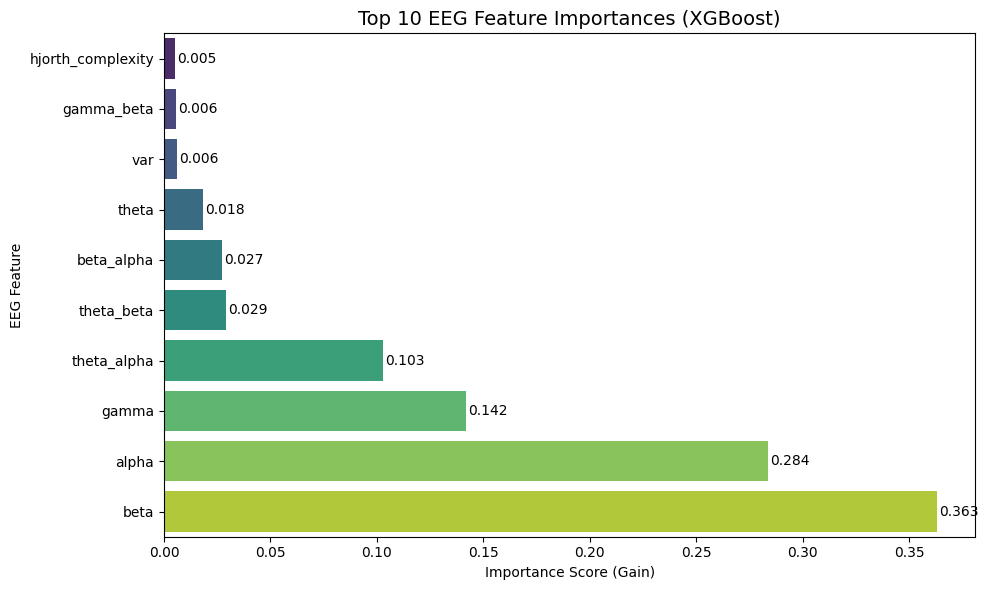

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get feature importance scores
importance = xgb_clf.feature_importances_

# Map to your feature names
feature_names = [
    "theta","alpha","beta","gamma",
    "mean","var","hjorth_activity",
    "hjorth_mobility","hjorth_complexity",
    "spectral_entropy",
    "theta_alpha","beta_alpha","gamma_beta","theta_beta"
]

# Create DataFrame
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=True).tail(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=feat_imp,
    x="Importance", y="Feature",
    palette="viridis"
)

# Annotate values
for i, v in enumerate(feat_imp["Importance"]):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center")

plt.title("Top 10 EEG Feature Importances (XGBoost)", fontsize=14)
plt.xlabel("Importance Score (Gain)")
plt.ylabel("EEG Feature")
plt.tight_layout()
plt.show()


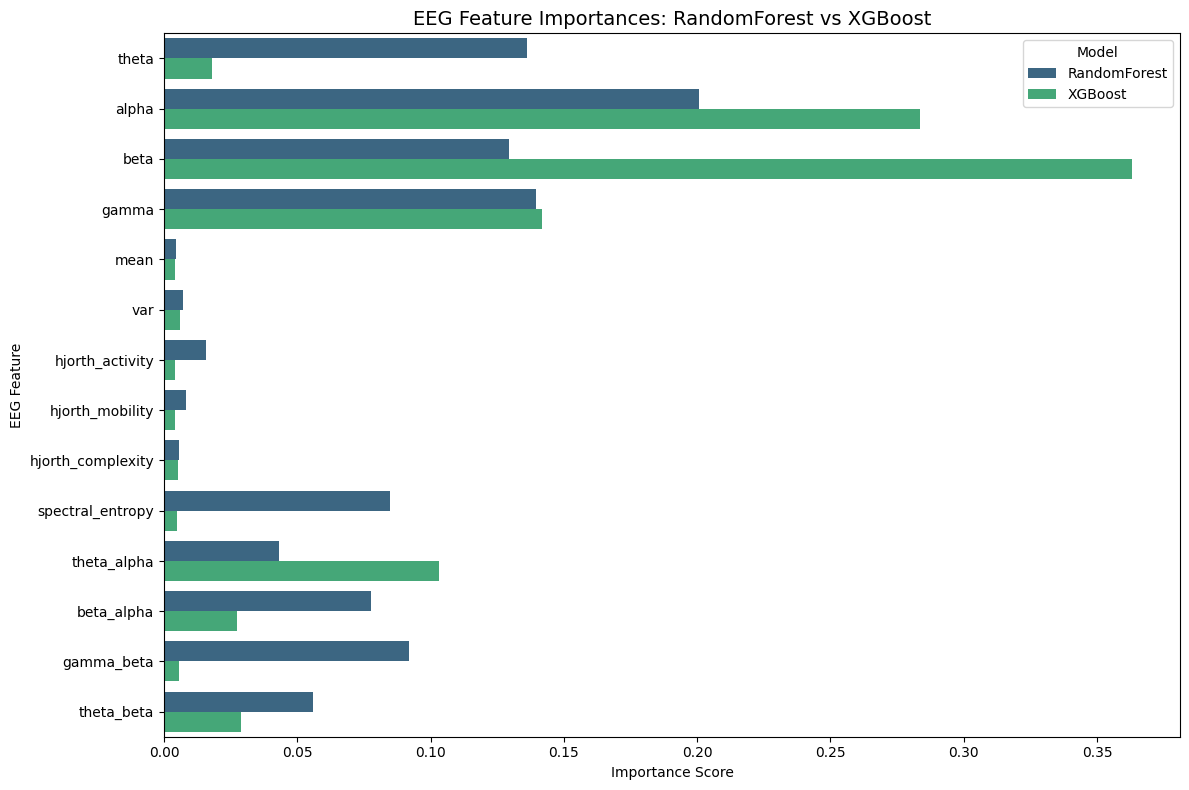

In [28]:
#Feature importance for Rf and XGBoost compared
# RandomForest feature importances
rf_importances = rf.feature_importances_

# XGBoost feature importances
xgb_importances = xgb_clf.feature_importances_

# Feature names (same order as your dataset)
feature_names = [
    "theta","alpha","beta","gamma",
    "mean","var","hjorth_activity",
    "hjorth_mobility","hjorth_complexity",
    "spectral_entropy",
    "theta_alpha","beta_alpha","gamma_beta","theta_beta"
]

import pandas as pd

df_rf = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances,
    "Model": "RandomForest"
})

df_xgb = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importances,
    "Model": "XGBoost"
})

# Combine
df_all = pd.concat([df_rf, df_xgb])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.barplot(
    data=df_all,
    x="Importance", y="Feature", hue="Model",
    palette="viridis"
)

plt.title("EEG Feature Importances: RandomForest vs XGBoost", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("EEG Feature")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


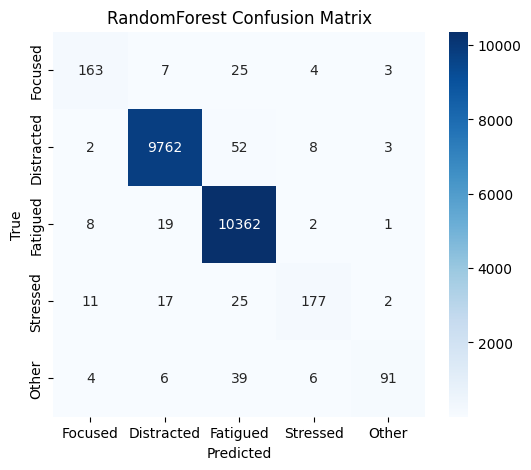

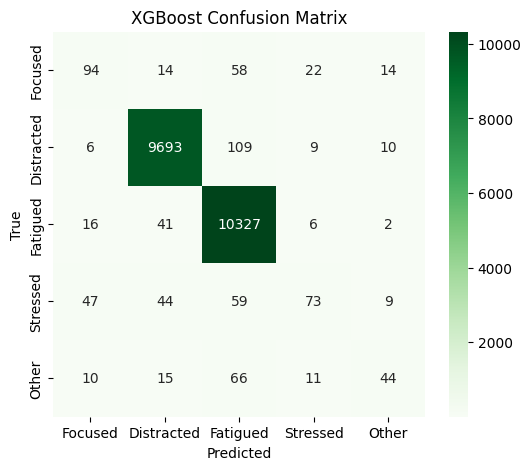

In [29]:
#Confusion matrices for Rf and XGBoost
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- RandomForest Confusion Matrix ---
y_pred_rf = rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("RandomForest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- XGBoost Confusion Matrix ---
y_pred_xgb = xgb_clf.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_names, yticklabels=target_names)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Step 5: EEGNET

In [30]:
def EEGNet(nb_classes, Chans=1, Samples=256, dropoutRate=0.5, kernLength=64, F1=8, D=2, F2=16, norm_rate=0.25):
    input1 = Input(shape=(Chans, Samples, 1))

    x = Conv2D(F1, (1, kernLength), padding='same', use_bias=False)(input1)
    x = BatchNormalization()(x)

    x = DepthwiseConv2D((Chans, 1), use_bias=False,
                        depth_multiplier=D,
                        depthwise_constraint=max_norm(1.))(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(dropoutRate)(x)

    x = SeparableConv2D(F2, (1, 16), use_bias=False, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8))(x)
    x = Dropout(dropoutRate)(x)

    x = Flatten()(x)
    x = Dense(nb_classes, kernel_constraint=max_norm(norm_rate))(x)
    x = Activation('softmax')(x)

    return Model(inputs=input1, outputs=x)




In [31]:

X_eegnet = X_raw.reshape((X_raw.shape[0], 1, X_raw.shape[1], 1))
print("EEGNet input shape:", X_eegnet.shape)


EEGNet input shape: (103992, 1, 256, 1)


In [32]:
# Train/test split
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(X_eegnet, y_raw, test_size=0.2, random_state=42)

# One-hot encode labels
num_classes = len(np.unique(y_raw))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)


In [33]:
eegnet = EEGNet(nb_classes=num_classes, Chans=1, Samples=X_train.shape[2])
eegnet.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


Step 6: Training

In [34]:
history = eegnet.fit(X_train, y_train_cat,
                     batch_size=64,
                     epochs=50,
                     validation_data=(X_test, y_test_cat),
                     verbose=1)


Epoch 1/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9322 - loss: 0.2996 - val_accuracy: 0.9415 - val_loss: 0.1846
Epoch 2/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9445 - loss: 0.1835 - val_accuracy: 0.9439 - val_loss: 0.1616
Epoch 3/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9478 - loss: 0.1653 - val_accuracy: 0.9566 - val_loss: 0.1467
Epoch 4/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.9499 - loss: 0.1560 - val_accuracy: 0.9571 - val_loss: 0.1387
Epoch 5/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.9511 - loss: 0.1506 - val_accuracy: 0.9573 - val_loss: 0.1360
Epoch 6/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9522 - loss: 0.1472 - val_accuracy: 0.9579 - val_loss: 0.1322
Epoch 7/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.9538 - loss: 0.1439 - val_accuracy: 0.9580 - val_loss: 0.1299
Epoch 8/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.9543 -

Step 7: Evaluation

650/650 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


c:\Users\Cyan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cyan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Cyan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

EEGNet Report:
               precision    recall  f1-score   support

     Focused       0.29      0.33      0.31       202
  Distracted       0.99      0.98      0.98      9829
    Fatigued       0.95      0.99      0.97     10406
    Stressed       0.33      0.01      0.02       233
       Other       0.00      0.00      0.00       129

    accuracy                           0.96     20799
   macro avg       0.51      0.46      0.46     20799
weighted avg       0.95      0.96      0.95     20799



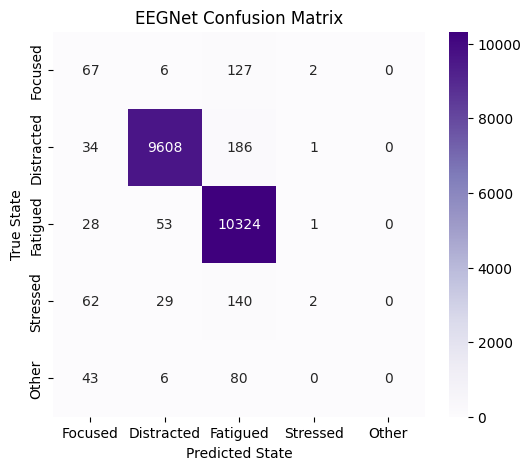

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


# Predictions on the correctly shaped EEGNet test set
y_pred_eegnet = eegnet.predict(X_test).argmax(axis=1)
y_true_eegnet = y_test_cat.argmax(axis=1)

# Classification report with state names
print("EEGNet Report:\n", classification_report(
    y_true_eegnet, y_pred_eegnet, target_names=class_names
))

# Confusion matrix with state names
cm_eegnet = confusion_matrix(y_true_eegnet, y_pred_eegnet)

plt.figure(figsize=(6,5))
sns.heatmap(cm_eegnet, annot=True, fmt="d", cmap="Purples",
            xticklabels=class_names, yticklabels=class_names)
plt.title("EEGNet Confusion Matrix")
plt.xlabel("Predicted State")
plt.ylabel("True State")
plt.show()


Correcting The Imbalances

In [36]:
#RF&XGBoost
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Build feature dataset
X_feat, y_feat = build_feature_dataset(all_files, window_sec=2, step_sec=1)

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_feat, y_feat)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# RandomForest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=class_names))

# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(np.unique(y_bal)),
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=class_names))


RF Accuracy: 0.9516853282969415
              precision    recall  f1-score   support

     Focused       0.98      0.94      0.96     10378
  Distracted       0.97      0.97      0.97     10377
    Fatigued       1.00      0.95      0.97     10378
    Stressed       0.95      0.91      0.93     10378
       Other       0.87      0.99      0.93     10378

    accuracy                           0.95     51889
   macro avg       0.95      0.95      0.95     51889
weighted avg       0.95      0.95      0.95     51889

XGB Accuracy: 0.8593728921351346
              precision    recall  f1-score   support

     Focused       0.78      0.77      0.78     10378
  Distracted       0.97      0.97      0.97     10377
    Fatigued       1.00      0.94      0.97     10378
    Stressed       0.78      0.73      0.75     10378
       Other       0.78      0.89      0.83     10378

    accuracy                           0.86     51889
   macro avg       0.86      0.86      0.86     51889
weighted avg

In [37]:
# EEGNET
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Train/test split for EEGNet
X_train, X_test, y_train, y_test = train_test_split(X_eegnet, y_raw, test_size=0.2, random_state=42)

# One-hot encode labels
num_classes = len(np.unique(y_raw))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Build EEGNet
eegnet = EEGNet(nb_classes=num_classes, Chans=1, Samples=X_train.shape[2])
eegnet.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train with class weights
history = eegnet.fit(X_train, y_train_cat,
                     batch_size=64,
                     epochs=50,
                     validation_data=(X_test, y_test_cat),
                     class_weight=class_weights_dict,
                     verbose=1)


Epoch 1/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8857 - loss: 1.1314 - val_accuracy: 0.9359 - val_loss: 0.4676
Epoch 2/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.9055 - loss: 1.0298 - val_accuracy: 0.9245 - val_loss: 0.4421
Epoch 3/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - accuracy: 0.9042 - loss: 1.0053 - val_accuracy: 0.9320 - val_loss: 0.4528
Epoch 4/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9068 - loss: 0.9927 - val_accuracy: 0.9419 - val_loss: 0.3906
Epoch 5/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - accuracy: 0.9077 - loss: 0.9825 - val_accuracy: 0.9249 - val_loss: 0.4335
Epoch 6/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - accuracy: 0.9061 - loss: 0.9809 - val_accuracy: 0.9357 - val_loss: 0.3868
Epoch 7/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.9038 - loss: 0.9690 - val_accuracy: 0.9021 - val_loss: 0.5050
Epoch 8/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.9076 -

Evaluation of Balanced Rf,XGBoost & EEGNET

In [38]:
# Build feature dataset (2D: samples × features)
X_feat, y_feat = build_feature_dataset(all_files, window_sec=2, step_sec=1)

# Balance with SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_feat, y_feat)

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# RandomForest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RandomForest Report:\n", classification_report(y_test, y_pred_rf, target_names=class_names))

# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(np.unique(y_bal)),
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb, target_names=class_names))


RandomForest Report:
               precision    recall  f1-score   support

     Focused       0.98      0.94      0.96     10378
  Distracted       0.97      0.97      0.97     10377
    Fatigued       1.00      0.95      0.97     10378
    Stressed       0.95      0.91      0.93     10378
       Other       0.87      0.99      0.93     10378

    accuracy                           0.95     51889
   macro avg       0.95      0.95      0.95     51889
weighted avg       0.95      0.95      0.95     51889

XGBoost Report:
               precision    recall  f1-score   support

     Focused       0.78      0.77      0.78     10378
  Distracted       0.97      0.97      0.97     10377
    Fatigued       1.00      0.94      0.97     10378
    Stressed       0.78      0.73      0.75     10378
       Other       0.78      0.89      0.83     10378

    accuracy                           0.86     51889
   macro avg       0.86      0.86      0.86     51889
weighted avg       0.86      0.86     

In [39]:
# Raw EEG dataset reshaped for EEGNet
X_eegnet = X_raw.reshape((X_raw.shape[0], 1, X_raw.shape[1], 1))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_eegnet, y_raw, test_size=0.2, random_state=42)

# One-hot encode labels
num_classes = len(np.unique(y_raw))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Build EEGNet
eegnet = EEGNet(nb_classes=num_classes, Chans=1, Samples=X_train.shape[2])
eegnet.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train with class weights
history = eegnet.fit(X_train, y_train_cat,
                     batch_size=64,
                     epochs=50,
                     validation_data=(X_test, y_test_cat),
                     class_weight=class_weights_dict,
                     verbose=1)


Epoch 1/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.8578 - loss: 1.1818 - val_accuracy: 0.9211 - val_loss: 0.5447
Epoch 2/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.8882 - loss: 1.0587 - val_accuracy: 0.9256 - val_loss: 0.4798
Epoch 3/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.8984 - loss: 1.0216 - val_accuracy: 0.9427 - val_loss: 0.4310
Epoch 4/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9010 - loss: 0.9958 - val_accuracy: 0.9249 - val_loss: 0.4608
Epoch 5/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9057 - loss: 0.9880 - val_accuracy: 0.9197 - val_loss: 0.4078
Epoch 6/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.9053 - loss: 0.9776 - val_accuracy: 0.9161 - val_loss: 0.4416
Epoch 7/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9055 - loss: 0.9702 - val_accuracy: 0.9241 - val_loss: 0.4751
Epoch 8/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.9046 -

**Evaluation Strategy**

-Metrics to Compute
1. Accuracy: Overall correct predictions.

2. Macro‑F1: Average F1 across all classes (treats minority classes equally).

3. Balanced Accuracy: Average recall across all classes (avoids bias toward majority).

In [51]:
# Build feature dataset (2D: samples × features)
X_feat, y_feat = build_feature_dataset(all_files, window_sec=2, step_sec=1)

# Balance with SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_feat, y_feat)

# Train/test split
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# RandomForest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_feat, y_train_feat)
y_pred_rf = rf.predict(X_test_feat)

# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softmax', num_class=len(np.unique(y_bal)),
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train_feat, y_train_feat)
y_pred_xgb = xgb_clf.predict(X_test_feat)


In [52]:
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score, classification_report

# Build feature dataset (2D: samples × features)
X_feat, y_feat = build_feature_dataset(all_files, window_sec=2, step_sec=1)

# Balance with SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_feat, y_feat)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# RandomForest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RandomForest Macro-F1:", f1_score(y_test, y_pred_rf, average='macro'))
print("RandomForest Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=class_names))

# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(np.unique(y_bal)),
    eval_metric='mlogloss'
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Macro-F1:", f1_score(y_test, y_pred_xgb, average='macro'))
print("XGBoost Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=class_names))


RandomForest Accuracy: 0.9516853282969415
RandomForest Macro-F1: 0.9520456389639701
RandomForest Balanced Accuracy: 0.9516856353960229
              precision    recall  f1-score   support

     Focused       0.98      0.94      0.96     10378
  Distracted       0.97      0.97      0.97     10377
    Fatigued       1.00      0.95      0.97     10378
    Stressed       0.95      0.91      0.93     10378
       Other       0.87      0.99      0.93     10378

    accuracy                           0.95     51889
   macro avg       0.95      0.95      0.95     51889
weighted avg       0.95      0.95      0.95     51889

XGBoost Accuracy: 0.8593728921351346
XGBoost Macro-F1: 0.8595943816945913
XGBoost Balanced Accuracy: 0.8593749299510218
              precision    recall  f1-score   support

     Focused       0.78      0.77      0.78     10378
  Distracted       0.97      0.97      0.97     10377
    Fatigued       1.00      0.94      0.97     10378
    Stressed       0.78      0.73      

In [53]:
# Raw EEG dataset reshaped for EEGNet (4D)
X_eegnet = X_raw.reshape((X_raw.shape[0], 1, X_raw.shape[1], 1))

# Train/test split
X_train_eeg, X_test_eeg, y_train_eeg, y_test_eeg = train_test_split(
    X_eegnet, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# One-hot encode labels
num_classes = len(np.unique(y_raw))
y_train_cat = to_categorical(y_train_eeg, num_classes)
y_test_cat  = to_categorical(y_test_eeg, num_classes)

# Build EEGNet
eegnet = EEGNet(nb_classes=num_classes, Chans=1, Samples=X_train_eeg.shape[2])
eegnet.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = eegnet.fit(X_train_eeg, y_train_cat,
                     batch_size=64, epochs=50,
                     validation_data=(X_test_eeg, y_test_cat),
                     verbose=1)

# Predictions
y_pred_eegnet = eegnet.predict(X_test_eeg).argmax(axis=1)
y_true_eegnet = y_test_cat.argmax(axis=1)


Epoch 1/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.9329 - loss: 0.3073 - val_accuracy: 0.9524 - val_loss: 0.1856
Epoch 2/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9425 - loss: 0.1891 - val_accuracy: 0.9520 - val_loss: 0.1555
Epoch 3/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9461 - loss: 0.1702 - val_accuracy: 0.9567 - val_loss: 0.1445
Epoch 4/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9481 - loss: 0.1605 - val_accuracy: 0.9530 - val_loss: 0.1389
Epoch 5/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9501 - loss: 0.1541 - val_accuracy: 0.9579 - val_loss: 0.1327
Epoch 6/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9519 - loss: 0.1476 - val_accuracy: 0.9581 - val_loss: 0.1284
Epoch 7/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.9528 - loss: 0.1445 - val_accuracy: 0.9595 - val_loss: 0.1270
Epoch 8/50
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.9534 -

Confusion matrices on balanced datasets

In [54]:
def plot_confusion_matrix(model_name, y_true, y_pred, normalize=False, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = ".2f"
    else:
        fmt = "d"
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted State")
    plt.ylabel("True State")
    plt.show()


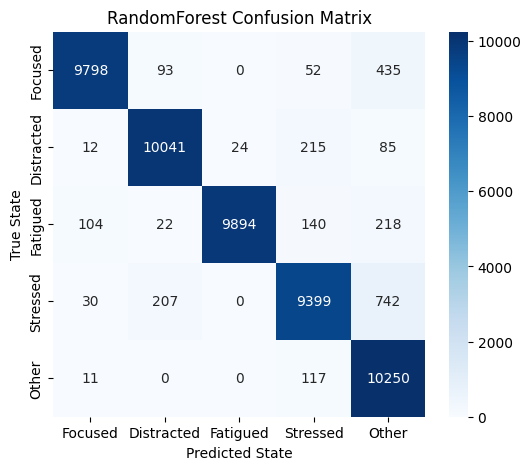

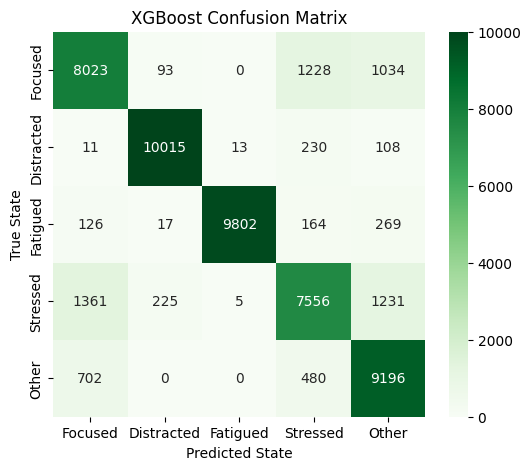

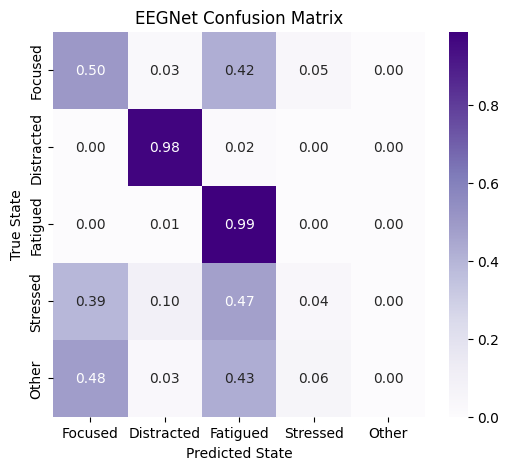

In [55]:
plot_confusion_matrix("RandomForest", y_test_feat, y_pred_rf, cmap="Blues")
plot_confusion_matrix("XGBoost", y_test_feat, y_pred_xgb, cmap="Greens")
plot_confusion_matrix("EEGNet", y_true_eegnet, y_pred_eegnet, cmap="Purples", normalize=True)


Oversampling Raw EEG Dataset

In [56]:
from imblearn.over_sampling import RandomOverSampler

# Flatten raw EEG epochs for oversampling
X_flat = X_raw.reshape((X_raw.shape[0], -1))
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_flat, y_raw)

# Reshape back to EEGNet format
X_res = X_res.reshape((X_res.shape[0], 1, X_res.shape[1], 1))


In [57]:
# Train/Test Split
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# One-hot encode labels
num_classes = len(np.unique(y_res))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)


In [58]:
# Build EEGNet
eegnet = EEGNet(nb_classes=num_classes, Chans=1, Samples=X_train.shape[2])
eegnet.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train (no need for class_weight now, dataset is balanced)
history = eegnet.fit(X_train, y_train_cat,
                     batch_size=64,
                     epochs=50,
                     validation_data=(X_test, y_test_cat),
                     verbose=1)


Epoch 1/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 159s 24ms/step - accuracy: 0.5691 - loss: 0.9795 - val_accuracy: 0.6095 - val_loss: 0.8654
Epoch 2/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 71s 22ms/step - accuracy: 0.6058 - loss: 0.8974 - val_accuracy: 0.6441 - val_loss: 0.8290
Epoch 3/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 63s 19ms/step - accuracy: 0.6179 - loss: 0.8727 - val_accuracy: 0.6614 - val_loss: 0.8050
Epoch 4/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 92s 22ms/step - accuracy: 0.6226 - loss: 0.8590 - val_accuracy: 0.6639 - val_loss: 0.7964
Epoch 5/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 78s 21ms/step - accuracy: 0.6258 - loss: 0.8525 - val_accuracy: 0.6678 - val_loss: 0.7922
Epoch 6/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 89s 23ms/step - accuracy: 0.6273 - loss: 0.8477 - val_accuracy: 0.6667 - val_loss: 0.7905
Epoch 7/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 70s 21ms/step - accuracy: 0.6291 - loss: 0.8431 - val_accuracy: 0.6588 - val_loss: 0.7882
Epoch 8/50
3248/3248 ━━━━━━━━━━━━━━━━━━━━ 71s 22ms/step - accuracy: 0.6330 

1624/1624 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step


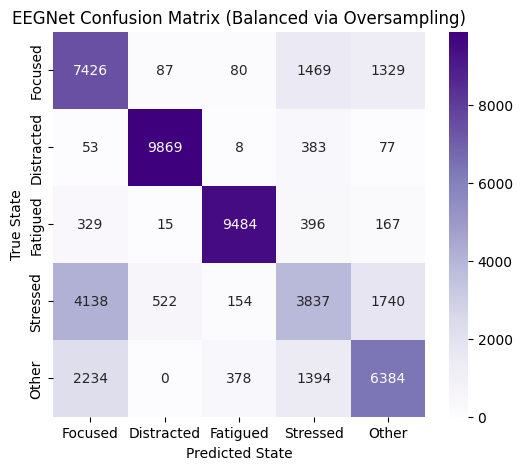

In [59]:
# Evaluate

# Predictions
y_pred_eegnet = eegnet.predict(X_test).argmax(axis=1)
y_true_eegnet = y_test_cat.argmax(axis=1)

# Confusion matrix
cm_eegnet = confusion_matrix(y_true_eegnet, y_pred_eegnet)


plt.figure(figsize=(6,5))
sns.heatmap(cm_eegnet, annot=True, fmt="d", cmap="Purples",
            xticklabels=target_names, yticklabels=target_names)
plt.title("EEGNet Confusion Matrix (Balanced via Oversampling)")
plt.xlabel("Predicted State")
plt.ylabel("True State")
plt.show()


In [64]:
# Timeline tracker
timeline = []

def log_prediction(predicted_state):
    timeline.append(predicted_state)


In [65]:
def adaptive_recommendation(predicted_state):
    log_prediction(predicted_state)
    
    counts = {state: timeline.count(state) for state in class_names}
    
    base_recs = {
        "Focused": "Continue with your current task — you are in a productive state.",
        "Distracted": "Try minimizing interruptions or use a focus technique (Pomodoro, noise-cancelling headphones).",
        "Fatigued": "Take a short break, hydrate, or do light stretching to recharge.",
        "Stressed": "Pause for breathing exercises or mindfulness to reduce stress.",
        "Other": "Review your environment — adjust lighting, posture, or take a reset break."
    }
    
    if predicted_state == "Fatigued" and counts["Fatigued"] >= 5:
        return "Frequent fatigue detected. Consider long-term strategies: sleep hygiene, nutrition, workload balance."
    elif predicted_state == "Stressed" and counts["Stressed"] >= 5:
        return "Frequent stress detected. Try structured relaxation routines or workload adjustments."
    elif predicted_state == "Distracted" and counts["Distracted"] >= 5:
        return "Repeated distraction detected. Consider environment changes: reduce notifications, set focus hours."
    else:
        return base_recs[predicted_state]


In [67]:
import matplotlib.pyplot as plt

def plot_state_timeline(timeline):
    plt.figure(figsize=(12,5))
    plt.plot(range(len(timeline)), timeline, marker='o', linestyle='-', color='purple')
    plt.xticks(range(len(timeline)), range(1, len(timeline)+1))
    plt.yticks(range(len(class_names)), class_names)
    plt.title("Predicted Mental State Timeline")
    plt.xlabel("Prediction Index")
    plt.ylabel("Mental State")
    plt.grid(True)
    plt.show()


650/650 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Stressed → Pause for breathing exercises or mindfulness to reduce stress.
Other → Review your environment — adjust lighting, posture, or take a reset break.
Fatigued → Take a short break, hydrate, or do light stretching to recharge.
Fatigued → Take a short break, hydrate, or do light stretching to recharge.
Distracted → Try minimizing interruptions or use a focus technique (Pomodoro, noise-cancelling headphones).
Fatigued → Take a short break, hydrate, or do light stretching to recharge.
Fatigued → Take a short break, hydrate, or do light stretching to recharge.
Distracted → Try minimizing interruptions or use a focus technique (Pomodoro, noise-cancelling headphones).
Fatigued → Frequent fatigue detected. Consider long-term strategies: sleep hygiene, nutrition, workload balance.
Fatigued → Frequent fatigue detected. Consider long-term strategies: sleep hygiene, nutrition, workload balance.
Fatigued → Frequent fatigue detected. Consider long-term

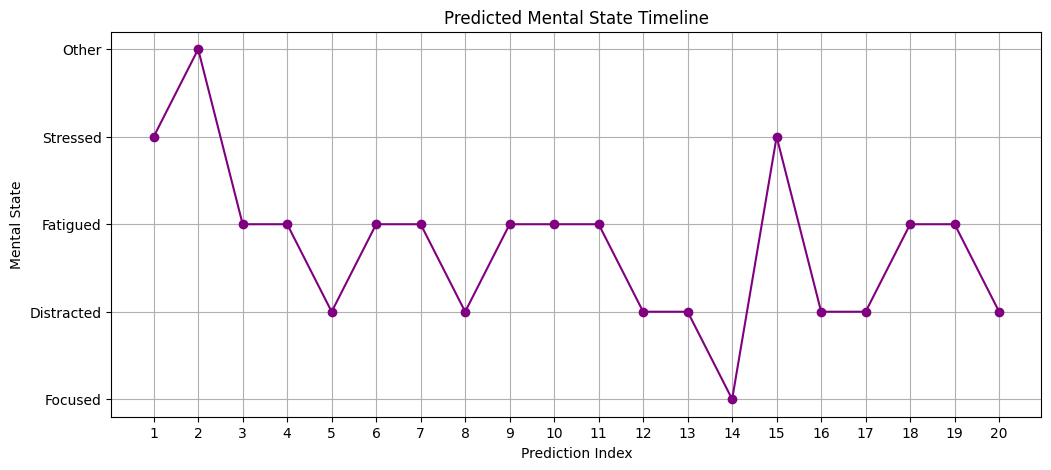

In [68]:
# Example: EEGNet predictions
y_pred_eegnet = eegnet.predict(X_test_eeg).argmax(axis=1)
predicted_states = [class_names[i] for i in y_pred_eegnet]

# Generate adaptive recommendations and log timeline
for state in predicted_states[:20]:
    print(f"{state} → {adaptive_recommendation(state)}")

# Plot timeline
plot_state_timeline([class_names.index(s) for s in timeline])


Streamlit deployment

In [75]:
import joblib

# Save RandomForest and XGBoost
joblib.dump(rf, "rf_model.pkl")
joblib.dump(xgb_clf, "xgb_model.pkl")

# Save EEGNet
eegnet.save("eegnet_model.h5")